In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.utils import resample
import optuna
from optuna.samplers import TPESampler
import warnings
from typing import Tuple, Dict, Any
warnings.filterwarnings('ignore')

In [ ]:
slices = pd.read_csv('slices_march.csv', parse_dates=['timestamp'])

# Стратифицированное разбиение по пассам
pass_labels = slices.groupby('ticket_number')['y_true'].max().reset_index()
pass_labels.columns = ['ticket_number', 'has_transfer']

train_pass, temp_pass = train_test_split(
    pass_labels['ticket_number'], test_size=0.3, random_state=42,
    stratify=pass_labels['has_transfer']
)
val_pass, test_pass = train_test_split(
    temp_pass, test_size=0.5, random_state=42,
    stratify=pass_labels[pass_labels['ticket_number'].isin(temp_pass)]['has_transfer']
)

train_df = slices[slices['ticket_number'].isin(train_pass)].copy()
val_df   = slices[slices['ticket_number'].isin(val_pass)].copy()

feature_cols = [c for c in slices.columns if c not in
                ['ticket_number', 'timestamp', 'y_true', 'is_labeled']]
X_train, y_train = train_df[feature_cols].values, train_df['y_true'].values
X_val, y_val     = val_df[feature_cols].values,   val_df['y_true'].values
groups_val = val_df['ticket_number'].values   # для Precision@k

Загрузка данных...


In [ ]:
# Функция Precision@k на уровне пассов
def precision_at_k(y_true, y_score, groups, k=20):
    df = pd.DataFrame({'score': y_score, 'label': y_true, 'ticket': groups})
    pass_max = df.groupby('ticket').agg(
        max_score=('score', 'max'),
        has_transfer=('label', 'max')
    ).reset_index()
    topk = pass_max.nlargest(k, 'max_score')
    return topk['has_transfer'].sum() / k

# Базовые гиперпараметры LightGBM
base_params = {
    'objective': 'binary',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'n_estimators': 500,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbosity': -1
}

In [ ]:
weights = [0.01, 0.05, 0.1, 0.2, 0.5]
precisions = []
aucs = []

for w in weights:
    print(f"\nВес немаркированных: {w}")
    # Веса: положительные (y=1) = 1.0, остальные = w
    sample_weight = np.where(y_train == 1, 1.0, w)

    model = lgb.LGBMClassifier(**base_params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(20), lgb.log_evaluation(0)]
    )

    y_pred = model.predict_proba(X_val)[:, 1]

    prec = precision_at_k(y_val, y_pred, groups_val, k=20)
    auc = roc_auc_score(y_val, y_pred)

    precisions.append(prec)
    aucs.append(auc)
    print(f"Precision@20 = {prec:.4f}, AUC = {auc:.4f}")


Вес немаркированных: 0.01
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[55]	valid_0's auc: 0.819252	valid_0's binary_logloss: 0.215938


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Precision@20 = 0.2000, AUC = 0.8193

Вес немаркированных: 0.05
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[21]	valid_0's auc: 0.8253	valid_0's binary_logloss: 0.0657119
Precision@20 = 0.2500, AUC = 0.8253

Вес немаркированных: 0.1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[66]	valid_0's auc: 0.828861	valid_0's binary_logloss: 0.0382111


...

Precision@20 = 0.1500, AUC = 0.8289

Вес немаркированных: 0.2
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[94]	valid_0's auc: 0.827084	valid_0's binary_logloss: 0.0264206


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Precision@20 = 0.2000, AUC = 0.8271

Вес немаркированных: 0.5
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[68]	valid_0's auc: 0.824623	valid_0's binary_logloss: 0.0211467


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Precision@20 = 0.2000, AUC = 0.8246


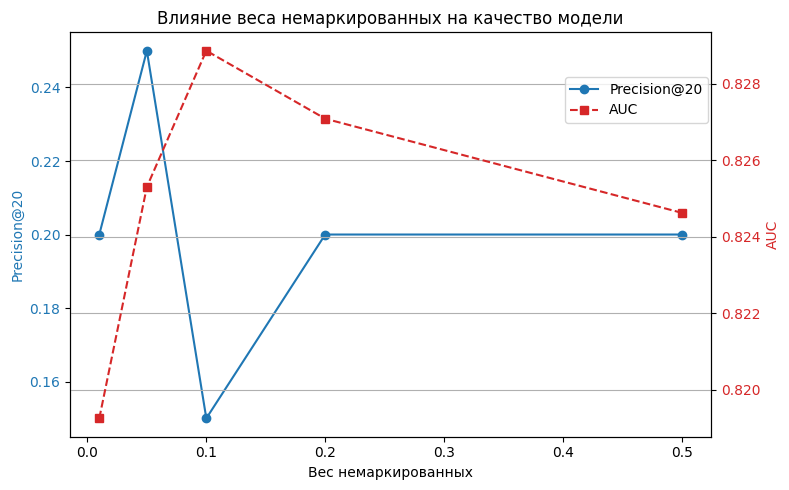

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:blue'
ax1.set_xlabel('Вес немаркированных')
ax1.set_ylabel('Precision@20', color=color1)
ax1.plot(weights, precisions, marker='o', color=color1, label='Precision@20')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('AUC', color=color2)
ax2.plot(weights, aucs, marker='s', color=color2, linestyle='--', label='AUC')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Влияние веса немаркированных на качество модели')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.grid(True)
plt.tight_layout()
plt.savefig('weight_validation_curve.png', dpi=150)
plt.show()

In [ ]:
RANDOM_STATE = 42
N_TRIALS = 100          # увеличено с 50 до 100
CV_FOLDS = 3            # кросс-валидация внутри Optuna
N_BAGGING_ESTIMATORS = 20   # для Bagging PU